In [1]:
import pandas as pd

In [2]:
d = pd.read_csv('133mVis_wavcal.csv',index_col=0,header=None)

In [3]:
m = d.values

Matrix shape: (44, 1024)


,row,slope,intercept,r2,rmse
0,0,0.004775,430.817928,0.999999,0.001004
1,1,0.004775,430.837074,0.999999,0.001010
2,2,0.004775,430.837033,0.999999,0.001011
3,3,0.004775,430.841851,0.999999,0.001012
4,4,0.004775,430.841862,0.999999,0.001012
5,5,0.004775,430.837055,0.999999,0.001011
6,6,0.004775,430.837062,0.999999,0.001010
7,7,0.004775,430.837088,0.999999,0.001011
8,8,0.004775,430.837095,0.999999,0.001011
9,9,0.004775,430.832269,0.999999,0.001009



Summary statistics:
              slope            r2       rmse
count  4.400000e+01  4.400000e+01  44.000000
mean   4.774983e-03  9.999995e-01   0.001007
std    3.342647e-08  2.576477e-09   0.000003
min    4.774911e-03  9.999995e-01   0.001004
25%    4.774953e-03  9.999995e-01   0.001005
50%    4.774993e-03  9.999995e-01   0.001006
75%    4.775014e-03  9.999995e-01   0.001009
max    4.775015e-03  9.999995e-01   0.001012


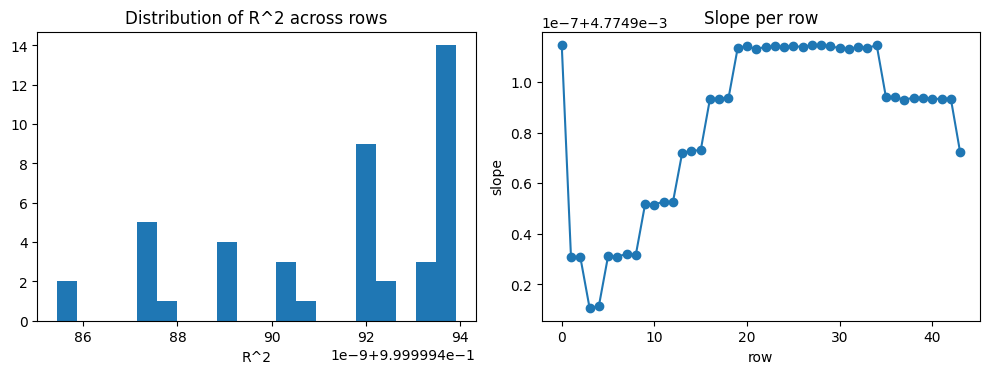


Worst-fitting rows (lowest R^2): [4, 3, 5, 8, 2, 7]


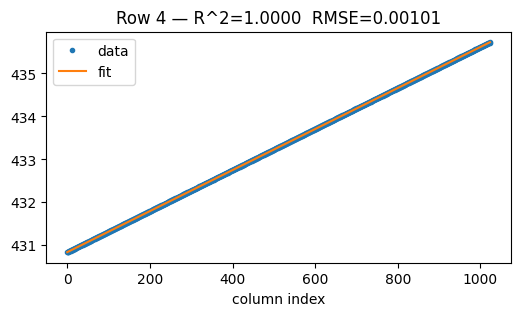

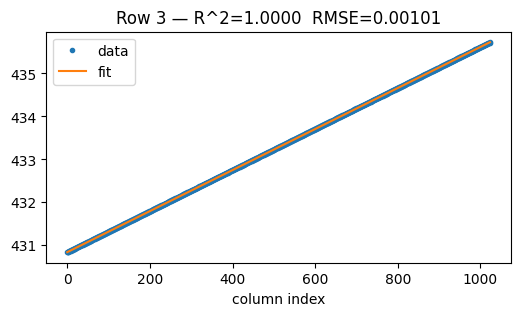

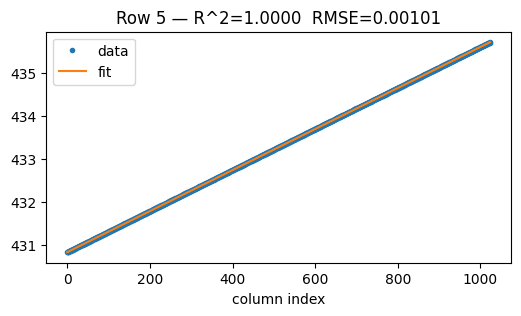

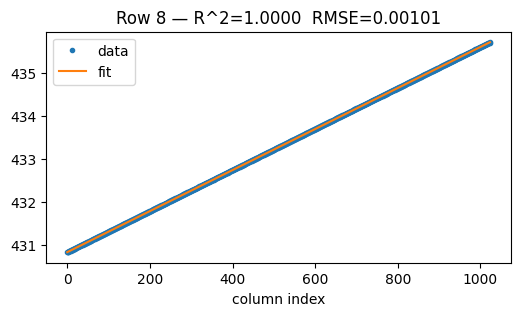

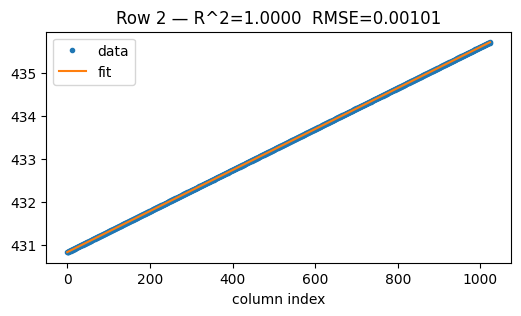

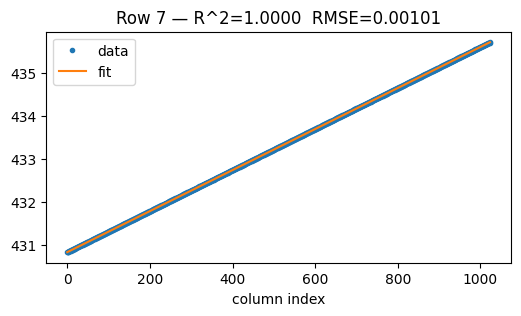


Saved summary to calibration_linearity_summary.csv


In [4]:
# Linear regression analysis for each row in the calibration matrix `m`
# Fits y = slope * x + intercept using column index as x and reports R^2 and RMSE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# `m` is expected to be defined earlier in the notebook (from the CSV)
# shape: (n_rows, n_cols)
try:
    m
except NameError:
    raise RuntimeError("Matrix `m` not found. Run the previous cells that load `133mVis_wavcal.csv` first.")

nrows, ncols = m.shape
x = np.arange(ncols)

slopes = np.full(nrows, np.nan)
intercepts = np.full(nrows, np.nan)
r2s = np.full(nrows, np.nan)
rmse = np.full(nrows, np.nan)

for i in range(nrows):
    y = m[i].astype(float)
    mask = np.isfinite(y)
    if mask.sum() < 2:
        continue
    # Linear fit
    p = np.polyfit(x[mask], y[mask], 1)
    yfit = np.polyval(p, x[mask])
    ss_res = np.sum((y[mask] - yfit) ** 2)
    ss_tot = np.sum((y[mask] - np.mean(y[mask])) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    rm = np.sqrt(ss_res / mask.sum())

    slopes[i] = float(p[0])
    intercepts[i] = float(p[1])
    r2s[i] = float(r2)
    rmse[i] = float(rm)

# Summary table
summary = pd.DataFrame({
    'row': np.arange(nrows),
    'slope': slopes,
    'intercept': intercepts,
    'r2': r2s,
    'rmse': rmse,
})

# Display summary and basic statistics
print(f"Matrix shape: {m.shape}")
display(summary)
print('\nSummary statistics:')
print(summary[['slope','r2','rmse']].describe())

# Plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(summary['r2'].dropna(), bins=20)
plt.xlabel('R^2')
plt.title('Distribution of R^2 across rows')

plt.subplot(1,2,2)
plt.plot(summary['row'], summary['slope'], 'o-')
plt.xlabel('row')
plt.ylabel('slope')
plt.title('Slope per row')
plt.tight_layout()
plt.show()

# Show worst-fitting rows for inspection
n_show = min(6, nrows)
bad_idx = np.argsort(summary['r2'].values)[:n_show]
print('\nWorst-fitting rows (lowest R^2):', bad_idx.tolist())
for i in bad_idx:
    y = m[i].astype(float)
    mask = np.isfinite(y)
    plt.figure(figsize=(6,3))
    plt.plot(x[mask], y[mask], '.', label='data')
    if not np.isnan(slopes[i]):
        plt.plot(x[mask], slopes[i] * x[mask] + intercepts[i], '-', label='fit')
    plt.title(f'Row {i} — R^2={r2s[i]:.4f}  RMSE={rmse[i]:.3g}')
    plt.xlabel('column index')
    plt.legend()
    plt.show()

# Save summary to CSV for further analysis
summary.to_csv('calibration_linearity_summary.csv', index=False)
print('\nSaved summary to calibration_linearity_summary.csv')
